Libraries Imported Successfully

Dataset Loaded Successfully

Dataset Shape:
(19947, 13)

Dataset Columns:
['id', 'title', 'user_id', 'profilename', 'review_time', 'review_text', 'review_length', 'combined_text', 'review_datetime', 'review_year', 'cleaned_text', 'cleaned_length', 'word_count']


,id,title,user_id,profilename,review_time,review_text,review_length,combined_text,review_datetime,review_year,cleaned_text,cleaned_length,word_count
0,0553804677,The Lies of Locke Lamora,ANAKK5KNUAP17,"Julio Caicedo ""Julio""",1217462400,Scott Lynch along with Patrick Rothfuss (The N...,894,The Lies of Locke Lamora Scott Lynch along wit...,2008-07-31,2008,lies locke lamora scott lynch along patrick ro...,605,92
1,0451519329,Great Expectations (Signet classics),NaN,NaN,1015027200,This is my least favorite book. I was forced t...,724,Great Expectations (Signet classics) This is m...,2002-03-02,2002,great expectations signet classics least favor...,504,74
2,1571892508,The Power of Kabbalah: Technology for the Soul,A2YVSH5CXYGR2B,"Latte2x ""latte2xbuzz""",1121558400,I've noticed that many people see a need to Be...,1931,The Power of Kabbalah: Technology for the Soul...,2005-07-17,2005,power kabbalah technology soul ive noticed man...,1227,164
3,0521630398,Language Teaching Awareness: A Guide to Explor...,NaN,NaN,949449600,This new book by Jerry Gebhard and Bob Oprandy...,844,Language Teaching Awareness: A Guide to Explor...,2000-02-02 00:00:00,2000,language teaching awareness guide exploring be...,646,78
4,8423671267,Las Luces de Septiembre (Spanish Edition),A17XJTSANMVOG6,Eduardo Mustelier,1244592000,I bought this one along with the first 2 publi...,821,Las Luces de Septiembre (Spanish Edition) I bo...,2009-06-10,2009,las luces septiembre spanish edition bought on...,519,73



Null Values Handled Successfully

Starting TF-IDF Vectorization...

TF-IDF Vectorization Completed

TF-IDF Shape:
(19947, 5000)

TF-IDF Vectorizer Saved Successfully

Top Feature Names:
['abandoned' 'abbey' 'abilities' 'ability' 'able' 'able put' 'abraham'
 'abridged' 'absence' 'absolute' 'absolutely' 'absurd' 'abuse' 'academic'
 'accept' 'acceptance' 'accepted' 'access' 'accessible' 'accident']

Numerical Features Created


,review_length,cleaned_length,word_count
0,894,605,92
1,724,504,74
2,1931,1227,164
3,844,646,78
4,821,519,73



Numerical Features Scaled

Scaler Saved Successfully

Final Feature Matrix Created

Final Feature Shape:
(19947, 5003)

Starting PCA...

PCA Completed

PCA Feature Shape:
(19947, 50)

PCA Model Saved Successfully

Cumulative Explained Variance:
0.778595744857


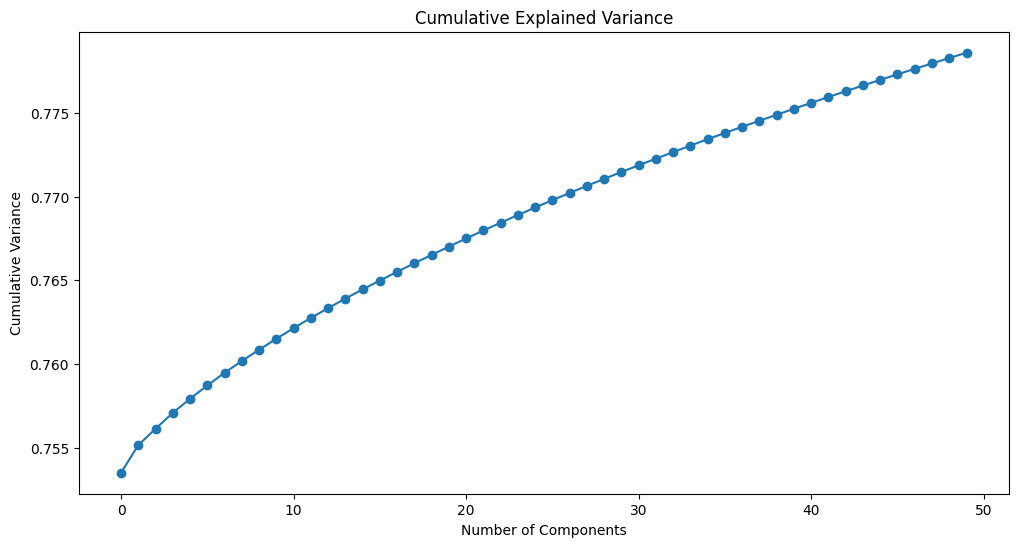


t-SNE Input Shape:
(5000, 50)

Starting t-SNE...

t-SNE Completed


,tsne_1,tsne_2
0,-52.931293,23.335726
1,56.695446,10.545752
2,42.298409,-23.086166
3,85.063927,13.822017
4,62.577713,-13.364014


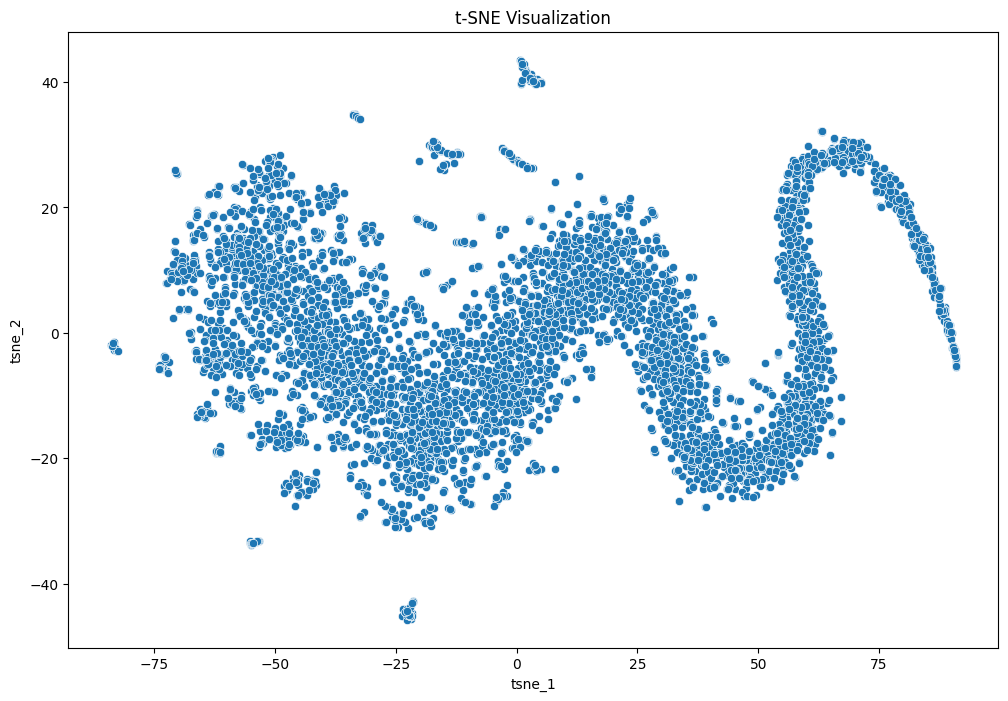


Top TF-IDF Words:


,word,score
440,book,0.058919
3551,read,0.034051
3073,one,0.025263
4219,story,0.021504
1974,great,0.020182
566,books,0.019074
2566,like,0.018981
1934,good,0.017832
4919,would,0.016957
4489,time,0.016141


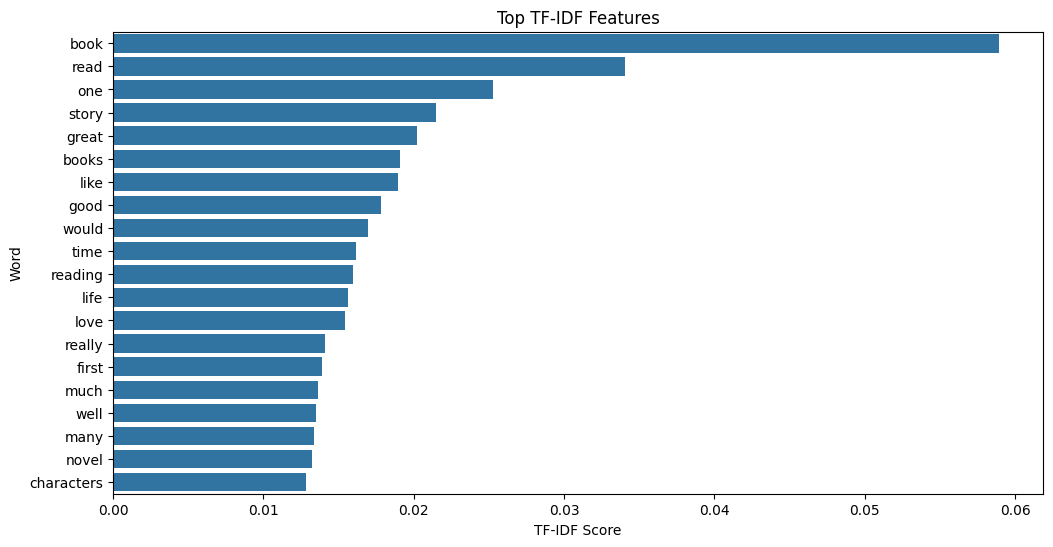


PCA Features Saved Successfully

t-SNE Features Saved Successfully

Feature Engineered Dataset Saved Successfully

Final Dataset Shape:
(19947, 13)

PCA Shape:
(19947, 50)

t-SNE Shape:
(5000, 2)

NOTEBOOK 03 COMPLETED SUCCESSFULLY

Tasks Completed:
1. TF-IDF Vectorization
2. N-Gram Feature Engineering
3. Numerical Feature Creation
4. Feature Scaling
5. Feature Combination
6. PCA Dimensionality Reduction
7. Explained Variance Analysis
8. t-SNE Visualization
9. TF-IDF Feature Analysis
10. Vectorizer Saved
11. PCA Model Saved
12. Feature Engineered Dataset Saved

Ready for Notebook 04 — Model Training


In [1]:
# ============================================================
# AMAZON BOOK REVIEWS CLUSTERING PROJECT
# NOTEBOOK: 03_feature_engineering.ipynb
# ============================================================

# ============================================================
# STEP 1 — IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import joblib

import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully")


# ============================================================
# STEP 2 — LOAD CLEANED DATASET
# ============================================================

DATA_PATH = (
    "../data/processed/"
    "cleaned_reviews.csv"
)

df = pd.read_csv(DATA_PATH)

print("\nDataset Loaded Successfully")

print("\nDataset Shape:")
print(df.shape)


# ============================================================
# STEP 3 — CHECK DATASET
# ============================================================

print("\nDataset Columns:")

print(df.columns.tolist())

display(df.head())


# ============================================================
# STEP 4 — HANDLE NULL VALUES
# ============================================================

df["cleaned_text"] = (
    df["cleaned_text"]
    .fillna("")
    .astype(str)
)

print("\nNull Values Handled Successfully")


# ============================================================
# STEP 5 — TF-IDF FEATURE ENGINEERING
# ============================================================

print("\nStarting TF-IDF Vectorization...")

tfidf_vectorizer = TfidfVectorizer(

    max_features=5000,

    ngram_range=(1,2),

    min_df=5,

    max_df=0.95
)

tfidf_features = tfidf_vectorizer.fit_transform(
    df["cleaned_text"]
)

print("\nTF-IDF Vectorization Completed")

print("\nTF-IDF Shape:")

print(tfidf_features.shape)


# ============================================================
# STEP 6 — SAVE TF-IDF VECTORIZER
# ============================================================

joblib.dump(

    tfidf_vectorizer,

    "../models/tfidf_vectorizer.pkl"
)

print("\nTF-IDF Vectorizer Saved Successfully")


# ============================================================
# STEP 7 — TF-IDF FEATURE NAMES
# ============================================================

feature_names = (
    tfidf_vectorizer
    .get_feature_names_out()
)

print("\nTop Feature Names:")

print(feature_names[:20])


# ============================================================
# STEP 8 — CREATE NUMERICAL FEATURES
# ============================================================

numerical_features = df[[
    "review_length",
    "cleaned_length",
    "word_count"
]]

print("\nNumerical Features Created")

display(
    numerical_features.head()
)


# ============================================================
# STEP 9 — SCALE NUMERICAL FEATURES
# ============================================================

scaler = StandardScaler()

scaled_numerical_features = scaler.fit_transform(
    numerical_features
)

print("\nNumerical Features Scaled")


# ============================================================
# STEP 10 — SAVE SCALER
# ============================================================

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

print("\nScaler Saved Successfully")


# ============================================================
# STEP 11 — COMBINE FEATURES
# ============================================================

from scipy.sparse import hstack

final_features = hstack([
    tfidf_features,
    scaled_numerical_features
])

print("\nFinal Feature Matrix Created")

print("\nFinal Feature Shape:")

print(final_features.shape)


# ============================================================
# STEP 12 — PCA DIMENSIONALITY REDUCTION
# ============================================================

print("\nStarting PCA...")

pca = PCA(
    n_components=50,
    random_state=42
)

pca_features = pca.fit_transform(
    final_features.toarray()
)

print("\nPCA Completed")

print("\nPCA Feature Shape:")

print(pca_features.shape)


# ============================================================
# STEP 13 — SAVE PCA MODEL
# ============================================================

joblib.dump(
    pca,
    "../models/pca_model.pkl"
)

print("\nPCA Model Saved Successfully")


# ============================================================
# STEP 14 — EXPLAINED VARIANCE
# ============================================================

explained_variance = (
    pca.explained_variance_ratio_
)

cumulative_variance = np.cumsum(
    explained_variance
)

print("\nCumulative Explained Variance:")

print(cumulative_variance[-1])


# ============================================================
# STEP 15 — PCA VARIANCE PLOT
# ============================================================

plt.figure(figsize=(12,6))

plt.plot(
    cumulative_variance,
    marker="o"
)

plt.title(
    "Cumulative Explained Variance"
)

plt.xlabel("Number of Components")

plt.ylabel("Cumulative Variance")

plt.show()


# ============================================================
# STEP 16 — t-SNE SAMPLING
# ============================================================

# IMPORTANT:
# t-SNE is computationally expensive

sample_size = 5000

if len(df) > sample_size:

    sample_indices = np.random.choice(
        len(df),
        sample_size,
        replace=False
    )

    tsne_input = pca_features[
        sample_indices
    ]

else:

    tsne_input = pca_features


print("\nt-SNE Input Shape:")

print(tsne_input.shape)


# ============================================================
# STEP 17 — APPLY t-SNE
# ============================================================

print("\nStarting t-SNE...")

tsne = TSNE(

    n_components=2,

    perplexity=30,

    random_state=42,

    learning_rate="auto"
)

tsne_features = tsne.fit_transform(
    tsne_input
)

print("\nt-SNE Completed")


# ============================================================
# STEP 18 — CREATE t-SNE DATAFRAME
# ============================================================

tsne_df = pd.DataFrame({

    "tsne_1": tsne_features[:,0],

    "tsne_2": tsne_features[:,1]
})

display(tsne_df.head())


# ============================================================
# STEP 19 — VISUALIZE t-SNE
# ============================================================

plt.figure(figsize=(12,8))

sns.scatterplot(

    x="tsne_1",

    y="tsne_2",

    data=tsne_df
)

plt.title("t-SNE Visualization")

plt.show()


# ============================================================
# STEP 20 — MOST IMPORTANT TF-IDF WORDS
# ============================================================

tfidf_scores = np.asarray(
    tfidf_features.mean(axis=0)
).flatten()

tfidf_df = pd.DataFrame({

    "word": feature_names,

    "score": tfidf_scores
})

top_tfidf_words = tfidf_df.sort_values(

    by="score",

    ascending=False
).head(20)

print("\nTop TF-IDF Words:")

display(top_tfidf_words)


# ============================================================
# STEP 21 — TF-IDF WORD VISUALIZATION
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(

    x="score",

    y="word",

    data=top_tfidf_words
)

plt.title("Top TF-IDF Features")

plt.xlabel("TF-IDF Score")

plt.ylabel("Word")

plt.show()


# ============================================================
# STEP 22 — SAVE PCA FEATURES
# ============================================================

pca_df = pd.DataFrame(pca_features)

pca_df.to_csv(

    "../data/processed/pca_features.csv",

    index=False
)

print("\nPCA Features Saved Successfully")


# ============================================================
# STEP 23 — SAVE t-SNE FEATURES
# ============================================================

tsne_df.to_csv(

    "../data/processed/tsne_features.csv",

    index=False
)

print("\nt-SNE Features Saved Successfully")


# ============================================================
# STEP 24 — SAVE FEATURE ENGINEERED DATASET
# ============================================================

df.to_csv(

    "../data/processed/feature_engineered_reviews.csv",

    index=False
)

print("\nFeature Engineered Dataset Saved Successfully")


# ============================================================
# STEP 25 — FINAL DATASET CHECK
# ============================================================

print("\nFinal Dataset Shape:")

print(df.shape)

print("\nPCA Shape:")

print(pca_features.shape)

print("\nt-SNE Shape:")

print(tsne_features.shape)


# ============================================================
# STEP 26 — PROJECT CHECKPOINT SUMMARY
# ============================================================

print("\n================================================")
print("NOTEBOOK 03 COMPLETED SUCCESSFULLY")
print("================================================")

print("\nTasks Completed:")

print("1. TF-IDF Vectorization")
print("2. N-Gram Feature Engineering")
print("3. Numerical Feature Creation")
print("4. Feature Scaling")
print("5. Feature Combination")
print("6. PCA Dimensionality Reduction")
print("7. Explained Variance Analysis")
print("8. t-SNE Visualization")
print("9. TF-IDF Feature Analysis")
print("10. Vectorizer Saved")
print("11. PCA Model Saved")
print("12. Feature Engineered Dataset Saved")

print("\nReady for Notebook 04 — Model Training")